In [3]:
from pathlib import Path
from typing import *
from dataclasses import dataclass
import zstandard as zstd

import numpy as np
import pandas as pd
import Bio
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

import matplotlib.pyplot as plt
from common.preprocess import *
from common.ml import MicrobiomeProject


NOTEBOOK_CACHE = Path("__tmp") / "asv_collect"
NOTEBOOK_CACHE.mkdir(exist_ok=True, parents=True)

In [4]:
data_base_dir = Path("/data/cctm/youn/human_microbiome_compendium")

project_metadata_file = data_base_dir / "projects.csv"
asv_sequence_file = data_base_dir / "obs_md.txt.zst"  # tsv format: ASV_NAME    ASV_SEQ, has a header.
abundance_table_dir = data_base_dir / "asv"
sample_metadata_file = data_base_dir / "sample_metadata.tsv"

assert asv_sequence_file.exists(), f"Expected {asv_sequence_file} to exist."
assert asv_sequence_file.is_file(), f"Expected {asv_sequence_file} to be a file."
assert abundance_table_dir.exists(), f"Expected {asv_sequence_file} to exist."
assert abundance_table_dir.is_dir(), f"Expected {abundance_table_dir} to be a directory."
assert sample_metadata_file.exists(), f"Expected {sample_metadata_file} to exist."
assert sample_metadata_file.is_file(), f"Expected {sample_metadata_file} to be a file."

""" Load the project metadata as a pandas dataframe. """
project_metadata = pd.read_csv(project_metadata_file, sep=',')
print("# projects:", project_metadata.shape[0])

""" Load the sample metadata as a pandas dataframe. """
sample_metadata = pd.read_csv(sample_metadata_file, sep='\t')
print("# samples:", sample_metadata.shape[0])

# projects: 482
# samples: 168464


# Dataframe manipulation

In [5]:
merged_df = project_metadata.loc[
    (project_metadata['condition'] == 'healthy')
    & (project_metadata['subjects'] == 'adults')
    & (project_metadata['amplicon'].isin({'v3-v4', 'v3', 'v4'}))
].merge(
    sample_metadata.groupby("project")['srs'].count().rename("n_samples").to_frame().reset_index(),
    left_on='project', right_on='project', how='left'
).sort_values("avg_length")

print("# rows:", merged_df.shape[0])
display(merged_df)
# for _, row in merged_df.tail(100).iterrows():
#     display(row.to_frame().transpose())

# rows: 48


,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes,n_samples
14,PRJEB6518,https://doi.org/10.1186/gb-2014-15-7-r89,v4,72.05,True,QIAamp DNA Stool Mini Kit (Qiagen),"stool, saliva",healthy,adults,NaN,534
39,PRJNA593062,https://doi.org/10.1016/j.cell.2020.05.001,v4,107.09,True,DNeasy Power Soil Kit(100),stool,healthy,adults,NaN,363
28,PRJNA472768,https://doi.org/10.1038/s41591-019-0485-4,v4,126.00,True,Mo Bio PowerSoil,stool,healthy,adults,NaN,208
7,PRJEB33065,https://doi.org/10.1128/mSystems.00864-19,v4,126.89,True,PowerSoil kit,stool,healthy,adults,NaN,262
3,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN,4850
4,PRJEB42056,https://doi.org/10.1128/mSystems.01329-20,v4,126.95,True,custom,"stool, saliva, skin",healthy,adults,NaN,84
8,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN,100
32,PRJNA388263,https://doi.org/10.1371/journal.pcbi.1005706,v4,132.28,True,PowerSoil -htp 96 Well Soil DNA Isolation Kit ...,stool,healthy,adults,NaN,443
37,PRJNA646360,https://doi.org/10.3390/nutraceuticals3010003,v3,196.58,True,Bead-beat Micro AX Gravity kit (A&A Biotechnol...,stool,healthy,adults,NaN,66
13,PRJEB6702,https://doi.org/10.1016/j.cell.2014.09.053,v4,203.00,True,PowerSoil - htp DNA isolation kit (MoBio Labor...,stool,healthy,adults,NaN,525


In [7]:
project_metadata.loc[
    project_metadata['project'].isin({'PRJEB36316', 'PRJEB11419'})
]

,project,link,amplicon,avg_length,bead_beating,kit,sample_type,condition,subjects,notes
41,PRJEB11419,https://doi.org/10.1128/mSystems.00031-18,v4,126.93,False,NaN,stool,healthy,adults,NaN
68,PRJEB36316,https://doi.org/10.1080/19490976.2020.1840764,v4,127.00,True,Quick-DNA Fecal/Soil Microbe Miniprep Kit,stool,healthy,adults,NaN


In [9]:
sample_metadata.loc[
    sample_metadata['project'] == 'PRJEB36316'
]

,srs,project,srr,library_strategy,library_source,pubdate,total_bases,instrument,geo_loc_name,iso,region
22255,ERS4256969,PRJEB36316,ERR3835205,AMPLICON,METAGENOMIC,2020-02-13 21:55:42,1.058821e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22256,ERS4256968,PRJEB36316,ERR3835204,AMPLICON,METAGENOMIC,2020-02-13 21:55:42,1.032349e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22257,ERS4256967,PRJEB36316,ERR3835203,AMPLICON,METAGENOMIC,2020-02-13 21:55:42,1.003706e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22258,ERS4256966,PRJEB36316,ERR3835202,AMPLICON,METAGENOMIC,2020-02-13 21:55:42,8.679130e+08,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22259,ERS4256965,PRJEB36316,ERR3835201,AMPLICON,METAGENOMIC,2020-02-13 21:55:42,9.413098e+08,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
...,...,...,...,...,...,...,...,...,...,...,...
22350,ERS4256874,PRJEB36316,ERR3835110,AMPLICON,METAGENOMIC,2020-02-13 21:55:41,1.088971e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22351,ERS4256873,PRJEB36316,ERR3835109,AMPLICON,METAGENOMIC,2020-02-13 21:55:41,1.018320e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22352,ERS4256872,PRJEB36316,ERR3835108,AMPLICON,METAGENOMIC,2020-02-13 21:55:41,9.485201e+08,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America
22353,ERS4256871,PRJEB36316,ERR3835107,AMPLICON,METAGENOMIC,2020-02-13 21:55:41,1.031140e+09,Illumina NovaSeq 6000,netherlands,NL,Europe and Northern America


# Preliminary filtering

In [26]:
PROJECT_IDS = set(
    merged_df.loc[
        merged_df['avg_length'] >= 100,
        'project'
    ]
)
print(PROJECT_IDS)
project_subset = project_metadata.loc[
    project_metadata['project'].isin(PROJECT_IDS), 
    :
]

sample_subset = sample_metadata.loc[
    (
        sample_metadata['project'].isin(PROJECT_IDS)
    )
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

{'PRJEB23775', 'PRJNA622517', 'PRJNA428736', 'PRJNA709129', 'PRJNA625181', 'PRJNA630848', 'PRJNA398279', 'PRJNA577051', 'PRJEB31155', 'PRJNA308315', 'PRJEB32537', 'PRJNA401981', 'PRJNA716437', 'PRJDB10612', 'PRJNA540406', 'PRJEB35769', 'PRJNA400325', 'PRJNA414540', 'PRJNA603983', 'PRJNA642894', 'PRJEB42056', 'PRJNA693579', 'PRJNA742936', 'PRJEB33905', 'PRJEB33065', 'PRJNA472768', 'PRJNA388263', 'PRJNA646360', 'PRJEB11419', 'PRJNA547591', 'PRJNA378749', 'PRJNA743361', 'PRJNA544527', 'PRJNA495320', 'PRJDB10527', 'PRJEB6705', 'PRJEB36316', 'PRJNA701870', 'PRJNA644097', 'PRJNA726866', 'PRJNA600229', 'PRJNA369083', 'PRJNA528754', 'PRJNA422125', 'PRJNA593062', 'PRJEB6702', 'PRJEB40569'}
[*] Stage 1 filter: 17794 samples remaining


In [27]:
project_subset, sample_subset, asv_seqs_subset, sample_max_num_asvs = filter_samples_and_asvs(
    project_subset, sample_subset,
    abundance_table_dir=abundance_table_dir,
    asv_sequence_file=asv_sequence_file,
)

[Project PRJDB10527] Read count statistics:
         read_counts
count      91.000000
mean   143661.780220
std     27889.617773
min     66694.000000
25%    125450.000000
50%    145938.000000
75%    161702.500000
max    203989.000000
[Project PRJDB10527] Using read count threshold of 93219.5 < x < 185246.5
*********************************
[Project PRJDB10612] Read count statistics:
        read_counts
count    117.000000
mean   12145.264957
std     4989.615282
min     5306.000000
25%     9002.000000
50%    10806.000000
75%    13659.000000
max    32130.000000
[Project PRJDB10612] Using read count threshold of 7057.6 < x < 21482.199999999997
*********************************
[Project PRJEB11419] Read count statistics:
         read_counts
count    4850.000000
mean    68171.349072
std    152080.475485
min         1.000000
25%     17341.750000
50%     22169.500000
75%     33531.500000
max    993123.000000
[Project PRJEB11419] Using read count threshold of 7738.8 < x < 534978.0000000001
***

In [29]:
print("# samples:", sample_subset.shape[0])

# samples: 12074


# Pre-screen ASVs for 16s.

In [30]:
ASV_SEQ_PROCESSING_DIR = NOTEBOOK_CACHE / "asv_16s_processing"
ASV_SEQ_PROCESSING_DIR.mkdir(exist_ok=True, parents=True)

"""
Note: defer_to_hpc option makes this pipeline print HPC instructions and raise an error.
Follow the directions, and re-run this cell.
"""
asv_seqs_subset = pipeline_16s_validation(
    asv_seqs_subset,
    cache_dir=ASV_SEQ_PROCESSING_DIR,
    silva_db=data_base_dir / "silva_nr99_v138.2_train_set.fa.gz",
    vsearch_path='vsearch',
    vsearch_num_threads=12,
    min_identity=0.95,
)

Wrote 145803 sequences to __tmp/asv_collect/asv_16s_processing/asv_sequences.fasta
VSEARCH found: vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
Found 145803 sequences in input file.
Using database: /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz
Minimum identity threshold: 95.0%
Strategy: Keeping only bacterial sequences, filtering out Archaea and Eukaryota

Running VSEARCH on __tmp/asv_collect/asv_16s_processing/asv_sequences.fasta against /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz...
Running command: vsearch --usearch_global __tmp/asv_collect/asv_16s_processing/asv_sequences.fasta --db /data/cctm/youn/human_microbiome_compendium/silva_nr99_v138.2_train_set.fa.gz --id 0.95 --maxaccepts 5 --maxrejects 32 --threads 12 --blast6out __tmp/asv_collect/asv_16s_processing/vsearch_results.tsv --top_hits_only
VSEARCH stderr:
vsearch v2.30.4_linux_x86_64, 62.5GB RAM, 32 cores
https://github.com/torognes/vsearch

Reading file /

Max ASV sequence length: 489


Text(0, 0.5, 'Count')

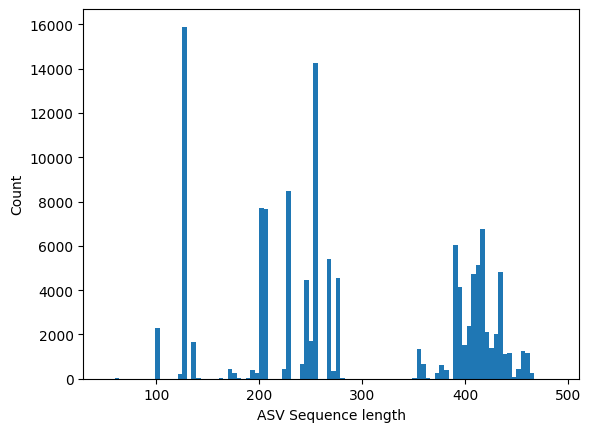

In [32]:
""" Compute the max sequence length. """
MAX_ASV_SEQUENCE_LEN = max(len(s) for s in asv_seqs_subset.values())
print("Max ASV sequence length:", MAX_ASV_SEQUENCE_LEN)

""" Plot ASV length frequency histogram """
fig, ax = plt.subplots(1, 1)
ax.hist([len(s) for s in asv_seqs_subset.values()], bins=100)
ax.set_xlabel("ASV Sequence length")
ax.set_ylabel("Count")

# Align ASVs to reference 16S.

In [34]:
""" Helper function: run MAFFT """
import subprocess

def run_mafft_addfragments(existing_alignment, fragments_fasta, output_alignment, mafft_path="mafft", extra_args=None):
    """
    Calls MAFFT with --addfragments to add short/fragment sequences to an existing alignment.

    Args:
        existing_alignment (str): Path to the existing alignment FASTA file.
        fragments_fasta (str): Path to the fragments (unaligned) FASTA file.
        output_alignment (str): Path for the output alignment FASTA file.
        mafft_path (str): Path to the MAFFT executable (default: "mafft").
        extra_args (list): Optional list of extra command-line args to pass (e.g. ["--thread", "4"]).

    Returns:
        int: Return code from the MAFFT subprocess.
    """
    cmd = [
        mafft_path,
        "--auto",
        "--addfragments", fragments_fasta,
    ]
    if extra_args:
        cmd.extend(extra_args)
    cmd += [existing_alignment]
    with open(output_alignment, "wt") as outfile:
        proc = subprocess.run(cmd, stdout=outfile)
    return proc.returncode

In [37]:
PROJECT_IDS

{'PRJDB10527',
 'PRJDB10612',
 'PRJEB11419',
 'PRJEB23775',
 'PRJEB31155',
 'PRJEB32537',
 'PRJEB33065',
 'PRJEB33905',
 'PRJEB35769',
 'PRJEB36316',
 'PRJEB40569',
 'PRJEB42056',
 'PRJEB6702',
 'PRJEB6705',
 'PRJNA308315',
 'PRJNA369083',
 'PRJNA378749',
 'PRJNA388263',
 'PRJNA398279',
 'PRJNA400325',
 'PRJNA401981',
 'PRJNA414540',
 'PRJNA422125',
 'PRJNA428736',
 'PRJNA472768',
 'PRJNA495320',
 'PRJNA528754',
 'PRJNA540406',
 'PRJNA544527',
 'PRJNA547591',
 'PRJNA577051',
 'PRJNA593062',
 'PRJNA600229',
 'PRJNA603983',
 'PRJNA622517',
 'PRJNA625181',
 'PRJNA630848',
 'PRJNA642894',
 'PRJNA644097',
 'PRJNA646360',
 'PRJNA693579',
 'PRJNA701870',
 'PRJNA709129',
 'PRJNA716437',
 'PRJNA726866',
 'PRJNA742936',
 'PRJNA743361'}

In [39]:
from common.ml import MicrobiomeProject


def align_asvs(project_ids: List[str], asv_seqs: Dict[str, str], reference_16s_fasta: Path, tmp_dir: Path):
    """ Collect all ASVs from the designated projects, and perform MAFFT --addfragments with respect to the Ecoli reference 16S sequence. """
    tmp_dir.mkdir(exist_ok=True, parents=True)

    # Collect all ASV per project into a fasta file.
    for project_id in project_ids:
        proj = MicrobiomeProject(project_id, abundance_table_dir, sample_subset)
        proj_asv_ids = set()
        for sample in proj.samples:
            for sample_asv_id in sample.asv_ids:
                if sample_asv_id in asv_seqs:
                    proj_asv_ids.add(sample_asv_id)
        
        asv_fasta = tmp_dir / f"{project_id}.asvs.fa"
        with open(asv_fasta, "wt") as asv_fasta_file:
            for asv_id in proj_asv_ids:
                # Skip all ASVs that don't pass the filter.
                if asv_id not in asv_seqs:
                    continue

                # Append good ASV to mafft input.
                record = SeqRecord(
                    Seq(asv_seqs[asv_id]),
                    id=f"{project_id}:{asv_id}",
                    description=""
                )
                SeqIO.write([record], asv_fasta_file, "fasta")

        # run MAFFT (per project)
        output_aln = tmp_dir / f"{project_id}.aln.fa"
        run_mafft_addfragments(reference_16s_fasta, asv_fasta, output_aln, mafft_path="mafft", extra_args=['--thread', '20'])


align_asvs(
    PROJECT_IDS,
    asv_seqs_subset,
    Path(".") / "Ecoli_16S.fasta",
    tmp_dir=NOTEBOOK_CACHE / Path("alignments"),
)

nadd =  2234
npair =  2234
nseq =  2235
nlen =  1541
use multipair, weighti=2.7!
distout=h
nadd = 2234
generating a scoring matrix for nucleotide (dist=200) ... done
dndpre (nuc) Version 7.526
alg=X, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
20 thread(s)

generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
    0 / 1 (by thread   0) 

##### writing hat3
pairlocalalign (nuc) Version 7.526
alg=Y, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
20 thread(s)

nadd = 2234
ppenalty_ex = -10
nthread = 20
blosum 62 / kimura 200
sueff_global = 0.100000
norg = 1
njobc = 2
Loading 'hat3' ... 
done.
generating a scoring matrix for nucleotide (dist=200) ... done
Loading 'hat2n' (aligned sequences - new sequences) ... done.
Loading 'hat2i' (aligned sequences) ... done.
STEP 499 / 2234 (thread 7)                     
STEP 500 / 2234 (thread 3)                    
ccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc

# Report results.

What region of the reference 16S do the ASVs align to?
(report the modal start position, and the modal end position)

In [48]:
from Bio import SeqIO
from collections import Counter

def modal_aligned_start(fasta_path):
    print(f"Reading: {fasta_path}")
    records = list(SeqIO.parse(fasta_path, "fasta"))
    ref_seq = str(records[0].seq)
    fragment_records = records[1:]
    
    # Map reference columns (with gaps) to reference indices (gapless)
    ref_pos_map = []
    ref_index = 0
    for c in ref_seq:
        if c != '-':
            ref_pos_map.append(ref_index)
            ref_index += 1
        else:
            ref_pos_map.append(None)
    
    # Get start pos for each fragment
    starts = []
    for rec in fragment_records:
        seq = str(rec.seq)
        for i, base in enumerate(seq):
            if base != '-':
                ref_idx = ref_pos_map[i]
                if ref_idx is not None:
                    starts.append(ref_idx)
                    break  # Only first non-gap
    return Counter(starts).most_common(1)[0][0] if starts else None

def modal_aligned_end(fasta_path):
    records = list(SeqIO.parse(fasta_path, "fasta"))
    ref_seq = str(records[0].seq)
    fragment_records = records[1:]
    
    ref_pos_map = []
    ref_index = 0
    for c in ref_seq:
        if c != '-':
            ref_pos_map.append(ref_index)
            ref_index += 1
        else:
            ref_pos_map.append(None)
    
    ends = []
    for rec in fragment_records:
        seq = str(rec.seq)
        for i in range(len(seq) - 1, -1, -1):
            base = seq[i]
            if base != '-':
                ref_idx = ref_pos_map[i]
                if ref_idx is not None:
                    ends.append(ref_idx)
                    break  # Only last non-gap
    return 1+Counter(ends).most_common(1)[0][0] if ends else None


def infer_16s_position(project_ids: Set[str]) -> Iterator[Tuple[str, int, int]]:
    project_positions: Dict[str, Tuple[int, int]] = dict()
    ref_seq = SeqIO.read(Path(".") / "Ecoli_16S.fasta", "fasta").seq
    # print(ref_seq)
    for project_id in project_ids:
        aln_path = NOTEBOOK_CACHE / Path("alignments") / f"{project_id}.aln.fa"
        if aln_path.stat().st_size == 0:
            print(f"******** Project {project_id} had no alignments!")
            continue
        inferred_start_pos = modal_aligned_start(aln_path)
        inferred_end_pos = modal_aligned_end(aln_path)
        project_positions[project_id] = (inferred_start_pos, inferred_end_pos)
        # yield project_id, inferred_start_pos, inferred_end_pos
    return project_positions

In [49]:
positions = infer_16s_position(PROJECT_IDS)
for pid, (start, end) in infer_16s_position(PROJECT_IDS).items():
    print(f"{pid}: 16S position {start} --> {end} [len={end-start}]")

Reading: __tmp/asv_collect/alignments/PRJEB23775.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA622517.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA428736.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA709129.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA625181.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA630848.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA398279.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA577051.aln.fa
Reading: __tmp/asv_collect/alignments/PRJEB31155.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA308315.aln.fa
Reading: __tmp/asv_collect/alignments/PRJEB32537.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA401981.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA716437.aln.fa
Reading: __tmp/asv_collect/alignments/PRJDB10612.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA540406.aln.fa
Reading: __tmp/asv_collect/alignments/PRJEB35769.aln.fa
Reading: __tmp/asv_collect/alignments/PRJNA400325.aln.fa
Reading: __tmp/asv_collect/alignment

In [50]:
print(list(positions.keys()))

['PRJEB23775', 'PRJNA622517', 'PRJNA428736', 'PRJNA709129', 'PRJNA625181', 'PRJNA630848', 'PRJNA398279', 'PRJNA577051', 'PRJEB31155', 'PRJNA308315', 'PRJEB32537', 'PRJNA401981', 'PRJNA716437', 'PRJDB10612', 'PRJNA540406', 'PRJEB35769', 'PRJNA400325', 'PRJNA414540', 'PRJNA603983', 'PRJNA642894', 'PRJEB42056', 'PRJNA693579', 'PRJNA742936', 'PRJEB33905', 'PRJEB33065', 'PRJNA472768', 'PRJNA388263', 'PRJNA646360', 'PRJEB11419', 'PRJNA547591', 'PRJNA378749', 'PRJNA743361', 'PRJNA544527', 'PRJNA495320', 'PRJDB10527', 'PRJEB6705', 'PRJEB36316', 'PRJNA701870', 'PRJNA726866', 'PRJNA600229', 'PRJNA369083', 'PRJNA528754', 'PRJNA422125', 'PRJNA593062', 'PRJEB6702', 'PRJEB40569']


# Which ASVs to handle?

In [7]:
def get_asv_sequences() -> Iterator[Tuple[str, str]]:
    """ 
    Fetch all of the ASV sequences from the asv_sequence_file location. 
    :return: A generator over (<ASV_ID>, <ASV_SEQ>) tuples.
    """
    with zstd.open(asv_sequence_file, "rt") as f:
        header_line = f.readline()
        assert header_line.startswith("#OTU"), "Expected file to start with the header: `#OTU`"
        
        for line in f:
            tokens = line.strip().split("\t")
            assert len(tokens) == 2, f"Expected exactly two tokens. Got: {line}"

            asv_id, asv_seq = tokens[0], tokens[1]
            assert asv_id.startswith("ASV"), f"Expected token #1 to have prefix `ASV`. Got: {asv_id}"
            yield asv_id, asv_seq

In [8]:
""" Load ASV nucleotide sequences. """
asv_seqs_all = {}
for asv_id, asv_seq in get_asv_sequences():
    asv_seqs_all[asv_id] = asv_seq

print("# ASVs:", len(asv_seqs_all))

# ASVs: 3663370


In [7]:
# PROJECT_ID_SUBSET = {"PRJEB11419", "PRJEB36316", "PRJEB33065", "PRJNA472768"}
# PROJECT_ID_SUBSET = {"PRJEB11419"}
PROJECT_ID_SUBSET = set(merged_df.tail(30)['project'])


"""
First, filter by project ID and restrict to US/CA subjects and Illumina MiSeq experiments.
Then, filter out those samples which have an abnormal amount of read counts (outside of 2.5% <--> 97.5% quantile)
"""
project_subset = project_metadata.loc[
    project_metadata['project'].isin(PROJECT_ID_SUBSET), 
    :
]


sample_subset = sample_metadata.loc[
    (
        sample_metadata['project'].isin(PROJECT_ID_SUBSET)
    )
]
print("[*] Stage 1 filter: {} samples remaining".format(sample_subset.shape[0]))

# ========== attach read depth (total # of ASV reads) as a column.
sample_total_read_counts_all = []
for proj_id, proj_section in sample_subset.groupby('project'):
    with zstd.open(microbiome_sequencing_dir / f"{proj_id}.txt.zst", "rt") as f:
        counts_table = pd.read_csv(f, sep='\t').set_index("asv")    # load from file
        counts_table = counts_table[list(proj_section['srs'])]      # restroct to samples from sample_subset
        sample_total_reads = counts_table.sum(axis=0)               # compute total ASV read counts in each sample
        sample_total_read_counts_all.append(sample_total_reads)     # append to list for concatenation.

sample_total_read_counts_all = pd.concat(sample_total_read_counts_all).rename("read_counts").astype(int)
assert sample_total_read_counts_all.shape[0] == sample_subset.shape[0], f"Expected read count for each sample. Got: {sample_total_read_counts_all.shape[0]} vs {sample_subset.shape[0]}"

sample_subset = sample_subset.merge(
    sample_total_read_counts_all.to_frame(),
    left_on=['srs'], right_index=True,
    how='left'
)

# ========== filter by read count threshold. (perform this on a per-project basis)
sections = []
for (proj_id, instrument_name), sample_project_section in sample_subset.groupby(["project", "instrument"]):
    print(f"[Project {proj_id} : {instrument_name}] Read count statistics:")
    display(sample_project_section['read_counts'].describe().to_frame())

    read_count_ub = np.quantile(sample_project_section['read_counts'], q=0.95)
    read_count_lb = np.quantile(sample_project_section['read_counts'], q=0.05)
    print(f"[Project {proj_id} : {instrument_name}] Using read count threshold of {read_count_lb} < x < {read_count_ub}")
    sample_project_section = sample_project_section.loc[
        (sample_project_section['read_counts'] <= read_count_ub) & (sample_project_section['read_counts'] >= read_count_lb)
    ]
    sections.append(sample_project_section)
    print("*********************************")

sample_subset = pd.concat(sections, ignore_index=True)
print("[*] Stage 2 filter: {} samples remaining".format(sample_subset.shape[0]))
del sections

display(sample_subset.groupby('project')['iso'].value_counts().rename("count").to_frame())

# ========== Now cross-reference back after filtering by region/read depth.
project_subset = project_subset.loc[project_subset['project'].isin(set(sample_subset['project']))]

[*] Stage 1 filter: 5834 samples remaining
[Project PRJDB10527 : Illumina MiSeq] Read count statistics:


,read_counts
count,91.000000
mean,143661.780220
std,27889.617773
min,66694.000000
25%,125450.000000
50%,145938.000000
75%,161702.500000
max,203989.000000


[Project PRJDB10527 : Illumina MiSeq] Using read count threshold of 93219.5 < x < 185246.5
*********************************
[Project PRJDB8511 : Illumina MiSeq] Read count statistics:


,read_counts
count,114.000000
mean,26721.122807
std,3627.281359
min,10874.000000
25%,25106.250000
50%,26963.000000
75%,28879.500000
max,33322.000000


[Project PRJDB8511 : Illumina MiSeq] Using read count threshold of 21392.1 < x < 31799.649999999998
*********************************
[Project PRJEB16344 : Illumina MiSeq] Read count statistics:


...

,read_counts
count,101.000000
mean,112839.158416
std,36617.435410
min,3900.000000
25%,90164.000000
50%,111215.000000
75%,136616.000000
max,214414.000000


[Project PRJNA741048 : Illumina MiSeq] Using read count threshold of 67097.0 < x < 169259.0
*********************************
[Project PRJNA742936 : Illumina MiSeq] Read count statistics:


,read_counts
count,168.00000
mean,148932.75000
std,68626.98015
min,7516.00000
25%,112081.50000
50%,145541.50000
75%,171656.75000
max,532402.00000


[Project PRJNA742936 : Illumina MiSeq] Using read count threshold of 67292.35 < x < 223690.05000000002
*********************************
[*] Stage 2 filter: 5226 samples remaining


,,count
project,iso,
PRJDB10527,JP,81
PRJDB8511,JP,102
PRJEB16344,RU,513
PRJEB30495,unknown,54
PRJEB31155,unknown,63
PRJEB33905,unknown,800
PRJEB35769,DE,313
PRJEB38835,DE,200
PRJEB40569,FR,239


In [8]:
"""
Next, restrict the set of ASVs to only those found in the filtered set of samples.
Apply an additional filter on the ASVs: only keep ASVs which appear in >=1 sample with a read count of >=10.
Finally, remove samples with 0 of these filtered ASVs.
"""
def select_subset_asvs(project_ids: List[str], sample_subset: Set[str]) -> Tuple[Set[str], int, Set[str]]:
    """
    :return: A triple of objects (Set of ASV IDs, Max # of ASV per sample, subset of sample IDs). 
    The subset of sample IDs is guaranteed to be a subset of the input 'sample_subset'; it should be used for further downstream pre-filtering of samples.
    """
    asv_set = set()
    max_sample_asv = 0
    new_sample_id_subset = set()

    # Load all asv count tables.
    project_asv_tables = dict()
    for project_id in project_ids:
        with zstd.open(microbiome_sequencing_dir / f"{project_id}.txt.zst", "rt") as f:
            table = pd.read_csv(f, sep='\t').set_index("asv")
            project_sample_ids = set(table.columns)
            
            table = table[list(sample_subset.intersection(project_sample_ids))]
            project_asv_tables[project_id] = table
            print("[* Pre-ASV selection filtering] PROJECT {}: {} samples, {} ASVs".format(project_id, len(table.columns), len(table.index)))

    """
    Filter stage 1:

    For each ASV, which samples have this ASV with count >= read_count_lb? Then count the # of samples (np.sum) and filter by num_sample_lb.
    Note: compute the total sample tally across all projects (call df.add)
    """
    read_count_lb = 10
    num_sample_lb = 1
    print(f"Filtering ASVs by (# samples with count >= {read_count_lb}) >= {num_sample_lb}")
    asv_n_samples_overall = None
    for project_id, project_table in project_asv_tables.items():
        asv_n_samples = np.sum(project_table >= read_count_lb, axis=1)
        if asv_n_samples_overall is None:
            asv_n_samples_overall = asv_n_samples
        else:
            asv_n_samples_overall = asv_n_samples_overall.add(asv_n_samples, fill_value=0).astype(int)

    # Restrict table to those ASVs where # samples >= num_sample_lb
    for project_id, project_table in project_asv_tables.items():
        asv_mask = asv_n_samples_overall >= num_sample_lb
        # not all ASVs in asv_mask are present in project_table.
        project_table = project_table[asv_mask.loc[project_table.index]]
        assert set(asv_mask.loc[project_table.index].index) == set(project_table.index), "Pandas syntax didn't select the correct rows indexed by ASV id."
        project_asv_tables[project_id] = project_table

    """
    Filter stage 2:

    For each Sample, only keep it if it has 'min_num_asv' filtered ASVs from stage 1.
    Also, for memory constraints during training, filter by 'max_num_asv'.
    """
    min_num_asv = 50
    max_num_asv = 400
    for project_id, project_table in project_asv_tables.items():
        num_asv_per_sample = np.sum(project_table > 0, axis=0)
        samples_with_lb_asvs = num_asv_per_sample.loc[
            (num_asv_per_sample >= min_num_asv) & (num_asv_per_sample <= max_num_asv)
        ]
        project_table = project_table.loc[:, samples_with_lb_asvs.index.to_list()]
        project_asv_tables[project_id] = project_table


    """
    Finalize and report summary.
    """
    for project_id, project_table in project_asv_tables.items():
        print("[* Post-ASV selection filtering] PROJECT {}: {} samples, {} ASVs".format(project_id, len(project_table.columns), len(project_table.index)))
        for sample_id in project_table.columns.to_list():
            new_sample_id_subset.add(sample_id)
            sample_n_asvs = np.sum(project_table[sample_id] > 0)
            max_sample_asv = max(max_sample_asv, sample_n_asvs)

        this_asv_ids = set(project_table.index.to_list())
        print("This project contributes {} new ASVs after filtering.".format(len(this_asv_ids.difference(asv_set))))
        asv_set = asv_set.union(this_asv_ids)
    return asv_set, max_sample_asv, new_sample_id_subset 


asv_id_subset, MAX_NUM_ASVS, sample_id_subset_post_filter = select_subset_asvs(project_subset['project'].to_list(), sample_subset=set(sample_subset['srs'].tolist()))
print("Num. project-relevant ASVs:", len(asv_id_subset))
print("Per-sample max num. ASV:", MAX_NUM_ASVS)

# ======= Update the sample_subset and project_subset dataframes, since we removed some samples with 0 filtered ASVs.
sample_subset = sample_subset.loc[sample_subset['srs'].isin(sample_id_subset_post_filter)]
project_subset = project_subset.loc[project_subset['project'].isin(set(sample_subset['project']))]

# ======= Fetch the ASV sequences.
asv_seqs_subset = {
    asv_id: asv_seq 
    for asv_id, asv_seq in asv_seqs_all.items() 
    if asv_id in asv_id_subset
}

assert len(asv_seqs_subset) == len(asv_id_subset)

[* Pre-ASV selection filtering] PROJECT PRJDB8511: 102 samples, 4399 ASVs
[* Pre-ASV selection filtering] PROJECT PRJDB10527: 81 samples, 9030 ASVs
[* Pre-ASV selection filtering] PROJECT PRJNA625181: 148 samples, 3452 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB40569: 239 samples, 8957 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB30495: 54 samples, 3610 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB35769: 313 samples, 7718 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB38835: 200 samples, 5434 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB33905: 800 samples, 14580 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB31155: 63 samples, 625 ASVs
[* Pre-ASV selection filtering] PROJECT PRJEB16344: 513 samples, 19876 ASVs
[* Pre-ASV selection filtering] PROJECT PRJNA742936: 150 samples, 18577 ASVs
[* Pre-ASV selection filtering] PROJECT PRJNA644097: 117 samples, 1509 ASVs
[* Pre-ASV selection filtering] PROJECT PRJNA709129: 150 samples, 2951 ASVs
[* Pre-ASV selection fi

In [8]:
""" Finally, run BLAST & compute multiple alignments using MAFFT. """
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq

def dict_to_fasta(sequences_dict: Dict[str, str], output_file: Path):
    """
    Write sequences from dictionary to multi-FASTA file using BioPython.
    
    Parameters:
    -----------
    sequences_dict : dict
        Dictionary mapping sequence IDs to sequences
    output_file : str
        Path to output FASTA file
    """
    # Create SeqRecord objects
    seq_records = []
    for seq_id, sequence in sequences_dict.items():
        seq_record = SeqRecord(
            Seq(sequence),
            id=seq_id,
            description=""  # Empty description, just ID
        )
        seq_records.append(seq_record)
    
    # Write to FASTA file
    with open(output_file, "w") as handle:
        SeqIO.write(seq_records, handle, "fasta")
    
    print(f"Wrote {len(seq_records)} sequences to {output_file}")


""" 
Run BLAST validation. 
Note: this may take anywhere between 6-24 hours (on Alienware aurora r16, 'nt' database hosted in /data/cctm), depending on query size and database disk i/o throughput.
"""
from validate_16s import validate_all_16s

asv_sequence_file_preblast = NOTEBOOK_CACHE / "asv_sequences.preblast.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_preblast)

validation_output = NOTEBOOK_CACHE / "asv_blast_validation.txt"
rejected_output_path = NOTEBOOK_CACHE / "asv_blast_rejects.txt"
BLAST_DB = Path("/data/cctm/blast_dbs/core_nt/core_nt")
BLAST_NUM_THREADS=30

validate_all_16s(
    input_fasta=asv_sequence_file_preblast,
    output_path=validation_output,
    rejected_output_path=rejected_output_path,
    blast_db=BLAST_DB,
    n_threads=BLAST_NUM_THREADS,
    blastn_path='/data/local/youn/miniforge3/envs/evo/bin/blastn'
)

"""
Parse the file and refine the asv subset.
"""
with open(validation_output, "rt") as f:
    asv_id_subset = set()
    for line in f:
        line = line.strip()
        if len(line) == 0:
            continue
        asv_id_subset.add(line)

asv_seqs_subset = {asv_id: asv_seq for asv_id, asv_seq in asv_seqs_subset.items() if asv_id in asv_id_subset}
asv_sequence_file_postblast = NOTEBOOK_CACHE / "asv_sequences.postblast.fasta"
dict_to_fasta(asv_seqs_subset, asv_sequence_file_postblast)
assert len(asv_seqs_subset) == len(asv_id_subset)

Wrote 130553 sequences to __tmp/asv_collect/asv_sequences.preblast.fasta
BLAST+ found: 2.17.0+
Found 130553 sequences in input file.
Using database: nt
Minimum identity threshold: 95.0%
Strategy: Only keeping sequences where ALL top 5 hits are 16S

Running BLAST search on __tmp/asv_collect/asv_sequences.preblast.fasta against /data/cctm/blast_dbs/core_nt/core_nt...
Running command: /data/local/youn/miniforge3/envs/evo/bin/blastn -task megablast -query __tmp/asv_collect/asv_sequences.preblast.fasta -db /data/cctm/blast_dbs/core_nt/core_nt -outfmt 5 -out __tmp/asv_collect/blast_results.xml -evalue 1e-10 -max_target_seqs 5 -perc_identity 95.0 -max_hsps 1 -mt_mode 0 -num_threads 30


KeyboardInterrupt: 


KeyboardInterrupt



# Wrapper functions/classes

In [9]:
@dataclass
class SampleMetadata:
    library_strategy: str
    library_source: str
    total_bases: int
    instrument: str
    geo_loc_name: str
    iso: str
    region: str


class MicrobiomeSample:
    def __init__(self, sample_id: str):
        self.sample_id = sample_id
        self.read_counts: Dict[str, float] = dict()
        self._metadata = None

    @property
    def asv_ids(self) -> Set[str]:
        return set(self.read_counts.keys())

    def set_count(self, asv_id: str, count_value: int) -> None:
        self.read_counts[asv_id] = count_value

    @property
    def metadata(self) -> SampleMetadata:
        if self._metadata is None:
            df_row = sample_metadata.loc[sample_metadata['srs'] == self.sample_id]
            assert df_row.shape[0] == 1, "Expected 1 row of metadata for id {}, got: {}".format(self.sample_id, df_row.shape[0])
            df_row = df_row.head(1)
            self._metadata = SampleMetadata(
                df_row['library_strategy'], df_row['library_source'], df_row['total_bases'], 
                df_row['instrument'], df_row['geo_loc_name'], df_row['iso'], df_row['region']
            )
        return self._metadata

    def read_count_array(self, asv_id_subset: Optional[Set[str]] = None) -> Tuple[List[str], np.ndarray]:
        """
        Return read counts, formatted as a numpy array.
        Note that the ordering of the read counts is not guaranteed, and may depend on python version! Check the List[str] part of this method's output for the resulting order.
        :return: A pair (asv_ids, read_counts), where `read_counts` is the numpy array, and `asv_ids` is the order of the ASVs indexing the array.
        """
        if asv_id_subset is None:
            target_asv_ids = self.asv_ids
        else:
            target_asv_ids = asv_id_subset.intersection(self.asv_ids)
            
        asv_ids = []
        asv_reads = []
        for asv_id in target_asv_ids:
            asv_read_count = self.read_counts[asv_id]
            asv_ids.append(asv_id)
            asv_reads.append(asv_read_count)
        return asv_ids, np.array(asv_reads, dtype=int)

    def relative_abundance_array(self, asv_id_subset: Optional[Set[str]] = None) -> Tuple[List[str], np.ndarray]:
        """
        Return estimated relative abundances, formatted as a numpy array.
        :return: A pair (asv_ids, rel_abunds), where `rel_abunds` is the numpy array, and `asv_ids` is the order of the ASVs indexing the array.
        """
        asv_ids, read_counts = self.read_count_array(asv_id_subset)
        return asv_ids, read_counts / np.sum(read_counts)

    def num_asvs(self) -> int:
        return len(self.read_counts)

    def __str__(self) -> str:
        return self.sample_id

    def __repr__(self) -> str:
        return f"Sample[{self.sample_id}]"


class MicrobiomeProject:
    def __init__(self, project_id: str):
        self.project_id = project_id
        self.samples, self.asv_ids = self.get_microbiome_sequencing(project_id)

    def __str__(self) -> str:
        return "Project[{}]".format(self.project_id)

    def __repr__(self) -> str:
        return "Project[{}]".format(self.project_id)

    @staticmethod
    def get_microbiome_sequencing(project_id) -> List[MicrobiomeSample]:    
        samples: List[MicrobiomeSample] = []
        asv_ids = set()
        with zstd.open(microbiome_sequencing_dir / f"{project_id}.txt.zst", "rt") as f:
            header_line = f.readline()
            assert header_line.startswith("asv\t"), f"Expected file to start with the header: `asv\\t`. Got: {header_line}"
    
            tokens = header_line.strip().split("\t")[1:]
            for sample_id in tokens:
                assert sample_id.startswith("DRS") or sample_id.startswith("SRS") or sample_id.startswith("ERS"), f"In {project_id}, expected sample ID to start with `DRS`, `SRS` or `ERS`. Got: {sample_id}"
                samples.append(MicrobiomeSample(sample_id))
    
            for line_idx, line in enumerate(f):
                tokens = line.strip().split("\t")
                asv_id = tokens[0]
                assert asv_id.startswith("ASV"), f"In {project_id}, line {line_idx+1}, expected asv ID to start with `ASV`. Got: {asv_id}"
                asv_ids.add(asv_id)
    
                assert len(tokens) == len(samples) + 1, f"In {project_id}, line {line_idx+1}, expected line to have {len(samples)+1} columns. Got: {len(tokens)}"
                for value_str, sample_obj in zip(tokens[1:], samples):
                    if value_str == "0.0":
                        continue
                    else:
                        sample_obj.set_count(asv_id, int(float(value_str)))
        return samples, asv_ids

ERROR! Session/line number was not unique in database. History logging moved to new session 23


# Comparison of ASVs and alignments.

In [10]:
""" Helper function: run MAFFT """
import subprocess

def run_mafft_addfragments(existing_alignment, fragments_fasta, output_alignment, mafft_path="mafft", extra_args=None):
    """
    Calls MAFFT with --addfragments to add short/fragment sequences to an existing alignment.

    Args:
        existing_alignment (str): Path to the existing alignment FASTA file.
        fragments_fasta (str): Path to the fragments (unaligned) FASTA file.
        output_alignment (str): Path for the output alignment FASTA file.
        mafft_path (str): Path to the MAFFT executable (default: "mafft").
        extra_args (list): Optional list of extra command-line args to pass (e.g. ["--thread", "4"]).

    Returns:
        int: Return code from the MAFFT subprocess.
    """
    cmd = [
        mafft_path,
        "--auto",
        "--addfragments", fragments_fasta,
    ]
    if extra_args:
        cmd.extend(extra_args)
    cmd += [existing_alignment]
    with open(output_alignment, "wt") as outfile:
        proc = subprocess.run(cmd, stdout=outfile)
    return proc.returncode

In [11]:
PROJECT_ID_SUBSET

{'PRJDB10527',
 'PRJDB8511',
 'PRJEB16344',
 'PRJEB30495',
 'PRJEB31155',
 'PRJEB33905',
 'PRJEB35769',
 'PRJEB38835',
 'PRJEB40569',
 'PRJNA369083',
 'PRJNA395034',
 'PRJNA400325',
 'PRJNA401981',
 'PRJNA422125',
 'PRJNA434249',
 'PRJNA481072',
 'PRJNA540406',
 'PRJNA550519',
 'PRJNA560950',
 'PRJNA600229',
 'PRJNA622517',
 'PRJNA625181',
 'PRJNA630848',
 'PRJNA642894',
 'PRJNA644097',
 'PRJNA709129',
 'PRJNA716437',
 'PRJNA726866',
 'PRJNA741048',
 'PRJNA742936'}

In [12]:
def align_asvs(project_ids: List[str], asv_seqs: Dict[str, str], reference_16s_fasta: Path, tmp_dir: Path):
    """ Collect all ASVs from the designated projects, and perform MAFFT --addfragments with respect to the Ecoli reference 16S sequence. """
    tmp_dir.mkdir(exist_ok=True, parents=True)

    # Collect all ASV per project into a fasta file.
    for project_id in project_ids:
        proj = MicrobiomeProject(project_id)
        asv_fasta = tmp_dir / f"{project_id}.asvs.fa"
        with open(asv_fasta, "wt") as asv_fasta_file:
            for asv_id in proj.asv_ids:
                # Skip all ASVs that don't pass the filter.
                if asv_id not in asv_seqs:
                    continue

                # Append good ASV to mafft input.
                record = SeqRecord(
                    Seq(asv_seqs[asv_id]),
                    id=f"{project_id}:{asv_id}",
                    description=""
                )
                SeqIO.write([record], asv_fasta_file, "fasta")

        # run MAFFT (per project)
        output_aln = tmp_dir / f"{project_id}.aln.fa"
        run_mafft_addfragments(reference_16s_fasta, asv_fasta, output_aln, mafft_path="/data/local/youn/miniforge3/envs/evo/bin/mafft", extra_args=['--thread', '20'])


align_asvs(
    PROJECT_ID_SUBSET,
    asv_seqs_subset,
    Path(".") / "Ecoli_16S.fasta",
    tmp_dir=NOTEBOOK_CACHE / Path("alignments"),
)

nadd =  6065
npair =  6065
nseq =  6066
nlen =  1541
use multipair, weighti=2.7!
distout=h
nadd = 6065
generating a scoring matrix for nucleotide (dist=200) ... done
dndpre (nuc) Version 7.526
alg=X, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
20 thread(s)

generating a scoring matrix for nucleotide (dist=200) ... done
All-to-all alignment.
    0 / 1 (by thread   9) 

##### writing hat3
pairlocalalign (nuc) Version 7.526
alg=Y, model=DNA200 (2), 2.00 (6.00), -0.10 (-0.30), noshift, amax=0.0
20 thread(s)

nadd = 6065
ppenalty_ex = -10
nthread = 20
blosum 62 / kimura 200
sueff_global = 0.100000
norg = 1
njobc = 2
Loading 'hat3' ... 
done.
generating a scoring matrix for nucleotide (dist=200) ... done
Loading 'hat2n' (aligned sequences - new sequences) ... done.
Loading 'hat2i' (aligned sequences) ... done.
cTEP 499 / 6065 (thread 15)                    
STEP 500 / 6065 (thread 16)                    
cccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccccc

KeyboardInterrupt: 

In [45]:
from Bio import SeqIO
from collections import Counter

def modal_aligned_start(fasta_path):
    records = list(SeqIO.parse(fasta_path, "fasta"))
    ref_seq = str(records[0].seq)
    fragment_records = records[1:]
    
    # Map reference columns (with gaps) to reference indices (gapless)
    ref_pos_map = []
    ref_index = 0
    for c in ref_seq:
        if c != '-':
            ref_pos_map.append(ref_index)
            ref_index += 1
        else:
            ref_pos_map.append(None)
    
    # Get start pos for each fragment
    starts = []
    for rec in fragment_records:
        seq = str(rec.seq)
        for i, base in enumerate(seq):
            if base != '-':
                ref_idx = ref_pos_map[i]
                if ref_idx is not None:
                    starts.append(ref_idx)
                    break  # Only first non-gap
    return Counter(starts).most_common(1)[0][0] if starts else None

def modal_aligned_end(fasta_path):
    records = list(SeqIO.parse(fasta_path, "fasta"))
    ref_seq = str(records[0].seq)
    fragment_records = records[1:]
    
    ref_pos_map = []
    ref_index = 0
    for c in ref_seq:
        if c != '-':
            ref_pos_map.append(ref_index)
            ref_index += 1
        else:
            ref_pos_map.append(None)
    
    ends = []
    for rec in fragment_records:
        seq = str(rec.seq)
        for i in range(len(seq) - 1, -1, -1):
            base = seq[i]
            if base != '-':
                ref_idx = ref_pos_map[i]
                if ref_idx is not None:
                    ends.append(ref_idx)
                    break  # Only last non-gap
    return 1+Counter(ends).most_common(1)[0][0] if ends else None


def infer_16s_position(project_ids: Set[str]) -> Iterator[Tuple[str, int, int]]:
    ref_seq = SeqIO.read(Path(".") / "Ecoli_16S.fasta", "fasta").seq
    # print(ref_seq)
    for project_id in project_ids:
        aln_path = NOTEBOOK_CACHE / Path("alignments") / f"{project_id}.aln.fa"
        inferred_start_pos = modal_aligned_start(aln_path)
        inferred_end_pos = modal_aligned_end(aln_path)
        yield project_id, inferred_start_pos, inferred_end_pos


for pid, start, end in infer_16s_position(PROJECT_ID_SUBSET):
    print(f"{pid}: 16S position {start} --> {end} [len={end-start}]")

PRJNA726866: 16S position 363 --> 804 [len=441]
PRJNA622517: 16S position 356 --> 783 [len=427]
PRJNA540406: 16S position 356 --> 783 [len=427]
PRJNA625181: 16S position 354 --> 787 [len=433]
PRJNA642894: 16S position 341 --> 799 [len=458]
PRJEB33905: 16S position 363 --> 780 [len=417]
PRJNA481072: 16S position 31 --> 511 [len=480]
PRJEB31155: 16S position 363 --> 780 [len=417]
PRJNA600229: 16S position 342 --> 801 [len=459]
PRJNA644097: 16S position 339 --> 804 [len=465]


In [ ]:
# class ProgressiveAlignments:
#     def __init__(self, state_dir: Path):
#         self.state_dir = state_dir
#         self.current_state = 0
#         self.asvs = set()

#     def increment_state(self) -> Tuple[int, int]:
#         prev = self.current_state
#         self.current_state += 1
#         return prev, self.current_state

#     def state_file(self, state: int, extension: str) -> Path:
#         return self.state_dir / f'{state}.{extension}'

#     def alignment_file(self, state: int) -> Path:
#         return self.state_file(state, 'aln.fa')

#     def fragment_file(self, state: int) -> Path:
#         return self.state_file(state, 'frag.fa')

#     def add_asvs(self, seqs: Dict[str, str]):
#         """
#         Increment the state, by performing the following actions:
#         1) Add ASVs to the current collection
#         2) update the FASTA file, and
#         3) perform alignment.
#         """
#         prev_state, next_state = self.increment_state()
#         next_frag = self.fragment_file(next_state)  # next fragment input for MAFFT.
#         prev_aln = self.alignment_file(prev_state)  # previous alignment result.
#         next_aln = self.alignment_file(next_state)  # next alignment result.

#         with open(next_frag, "wt") as f:
#             for asv_id, asv_seq in seqs.items():
#                 if asv_id in self.asvs:
#                     continue
#                 self.asvs.add(asv_id)
                

In [19]:
# def collect_asvs(project_ids: List[str], target_dir: Path):
#     assert target_dir.exists(), f"Directory {target_dir} does not exist!"
#     assert target_dir.is_dir(), f"Path {target_dir} must be a directory!"
#     for project_id in project_ids:
#         proj = MicrobiomeProject(project_id)
        

_IncompleteInputError: incomplete input (2663448555.py, line 5)